In [1]:
from joblib import load
import pandas as pd
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler
import numpy as np

import shap

In [2]:
df = pd.read_csv(r'C:\Users\jacop\OneDrive\Desktop\GIST\DATASET\Dataset_features_2D_preproc.csv')
X_train = df.query('subj  in [6,12,11,16,8,15]')[df.columns[:-2]].to_numpy()
y_train = df.query('subj  in [6,12,11,16,8,15]')[df.columns[-2]].to_numpy()
X_test  = df.query('subj  in [13,10,2]')[df.columns[:-2]].to_numpy()
y_test  = df.query('subj  in [13,10,2]')[df.columns[-2]].to_numpy()
features_name  = df.query('subj  in [13,10,2]')[df.columns[:-2]].columns


imputer,scaler = SimpleImputer(),StandardScaler()
X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test  = scaler.transform(imputer.transform(X_test))

In [ ]:
iron_man = load(r'experiment\202410101205\iron_man.joblib')

model = iron_man['best_model']
 
genes = iron_man['best_genes']
genes = np.array(genes,dtype = bool)
X_test_selected = X_test[:,genes]

In [4]:
def get_class_feature_importance(model, X_test):
    """
    Returns the SHAP feature importance for class 0 and class 1.
    
    Parameters:
    - model: trained model
    - X_test: test set features (pandas DataFrame or numpy array)
    
    Returns:
    - importance_class_0: SHAP values for class 0
    - importance_class_1: SHAP values for class 1
    """

    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # SHAP returns two arrays: one for class 0 and one for class 1 (binary classification)
    importance_class_0 = shap_values[0]
    importance_class_1 = shap_values[1]

    return importance_class_0, importance_class_1,shap_values

# Usage example (assuming you have a trained model and a test set):
# importance_0, importance_1 = get_class_feature_importance(trained_model, X_test)


In [5]:
importance_class_0, importance_class_1 ,shap_values= get_class_feature_importance(model, X_test_selected)

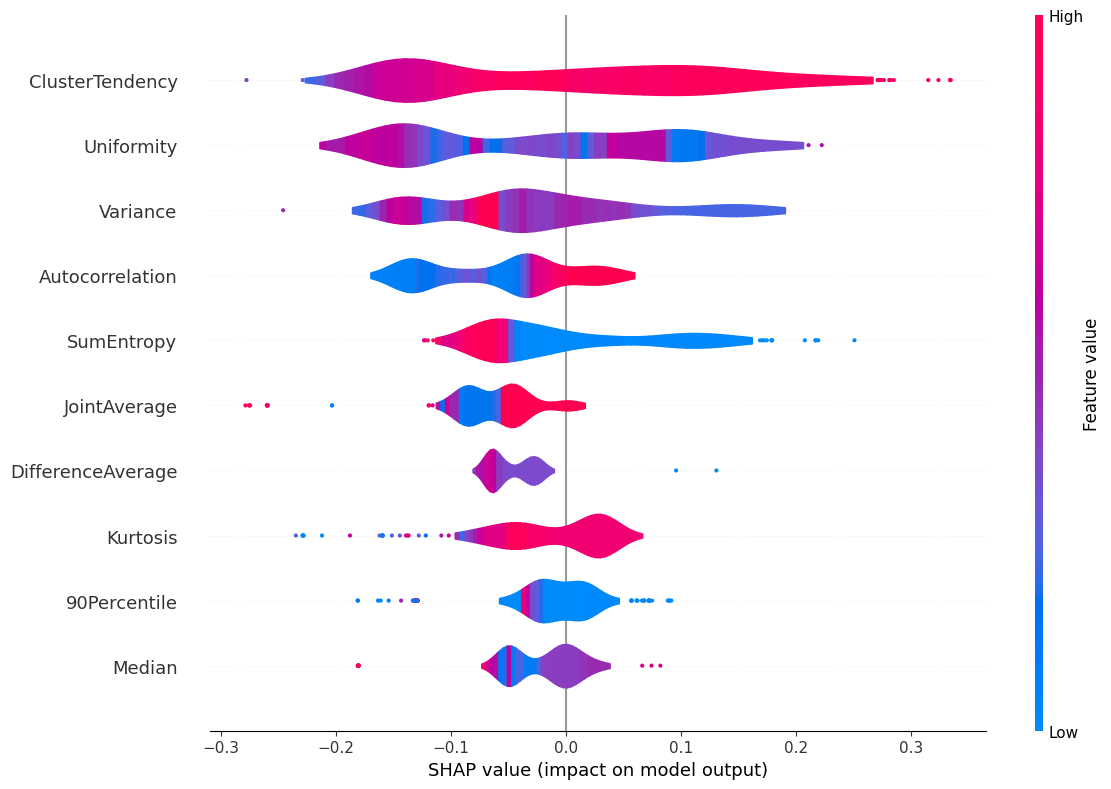

In [13]:
shap.summary_plot(shap_values[:,:,0], X_test_selected,[f.split('_')[1] for f in features_name], plot_type = 'violin', max_display = 10, plot_size = [12,8])